In [1]:
import pandas as pd
import matplotlib as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder            

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv", index_col=0)
y_train = pd.read_csv("../data/processed/y_train.csv", index_col=0)

X_test = pd.read_csv("../data/processed/X_test.csv", index_col=0)
y_test = pd.read_csv("../data/processed/y_test.csv", index_col=0)

In [3]:
X_train.sample(5)

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,...,Swallowing_Difficulty,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months
32,LC-0033,2020,2020-05-21,Europe,Netherlands,69,Male,Current Smoker,34,33,...,No,No,NSCLC,Large Cell,Stage IV,9.7,Yes,Bronchoscopy,Chemo + Radiation,11
203,LC-0204,2023,2023-11-10,Western Pacific,Australia,66,Male,Never Smoked,0,0,...,No,No,SCLC,Not Applicable,Stage III,4.2,No,PET Scan,Immunotherapy,7
640,LC-0641,2022,2022-04-08,Western Pacific,South Korea,70,Male,Former Smoker,16,14,...,No,Yes,NSCLC,Squamous Cell,Stage IV,7.8,Yes,Biopsy,Targeted Therapy,1
673,LC-0674,2015,2015-03-05,Western Pacific,China,67,Male,Former Smoker,3,15,...,No,No,NSCLC,Adenocarcinoma,Stage II,4.6,No,Bronchoscopy,Surgery,17
763,LC-0764,2024,2024-02-03,Eastern Mediterranean,Iraq,65,Male,Never Smoked,0,0,...,No,No,NSCLC,Squamous Cell,Stage IV,7.7,Yes,PET Scan,Targeted Therapy,9


In [4]:
# define numeric and categorical columns
num_cols = ['Age', 'BMI', 'Pack_Years']

cat_cols = ['WHO_Region','Country', 'Gender', 'Smoking_Status',
            'Air_Pollution_Exposure', 'Alcohol_Use', 'Exercise_Frequency',
             'Genetic_Mutation',  'Cancer_Type', 'NSCLC_Subtype', 
             'Diagnosis_Method', 'Treatment']

binary_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History', 'Coughing','Shortness_of_Breath', 
                'Chest_Pain', 'Coughing_Blood', 'Fatigue', 'Weight_Loss', 
                'Wheezing', 'Recurrent_Infections', 'Swallowing_Difficulty', 
                'Finger_Clubbing', 'Metastasis']


In [5]:
def clean_data(X):
    X = X.drop(['Patient_ID', 'Diagnosis_Year', 
                              'Diagnosis_Date', 'Survival_Months'], axis=1)
    return X

In [6]:
# removing columns again to reduce correlation instead of using PCA
def engineer_X(X):
    # adding pack_years as a feature (a standard clinical metric)
    X['Pack_Years'] = (X['Cigarettes_Per_Day'] / 20) * X['Years_Smoking']

    # changing cancer stage to ordinal values
    stage_map = {'Stage I': 1,
                 'Stage II': 2,
                 'Stage III': 3,
                 'Stage IV': 4}
    X['Cancer_Stage_Numeric'] = X['Cancer_Stage'].map(stage_map)

    # changing binary values to 1 and 0
    binary_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History', 'Coughing','Shortness_of_Breath', 
                'Chest_Pain', 'Coughing_Blood', 'Fatigue', 'Weight_Loss', 
                'Wheezing', 'Recurrent_Infections', 'Swallowing_Difficulty', 
                'Finger_Clubbing', 'Metastasis']

    X[binary_cols] = X[binary_cols].eq("Yes").astype(int)

    # converting gender values
    X['Gender'] = X['Gender'].eq("Male").astype(int)
    
    # converting cancer types
    X['Cancer_Type'] = X['Cancer_Type'].eq("NSCLC").astype(int)

    # creating a count column for symptoms and risk
    symptom_cols = ['Coughing','Shortness_of_Breath', 'Chest_Pain', 
                    'Coughing_Blood', 'Fatigue', 'Weight_Loss', 'Wheezing', 
                    'Recurrent_Infections', 'Swallowing_Difficulty', 
                    'Finger_Clubbing', 'Metastasis']
    X['Symptom_Count'] = X[symptom_cols].sum(axis=1).astype(int)

    risk_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History']
    X['Risk_Count'] = X[risk_cols].sum(axis=1).astype(int)

    X = X.drop(columns=['Cigarettes_Per_Day', 'Years_Smoking', 
                        'Cancer_Stage', 'Tumor_Size_cm'])

    return X


In [7]:
def bool_target(y):
    y['Survived'] = y['Survived'].eq("Yes").astype(int)
    return y

In [8]:
X_train = engineer_X(clean_data(X_train))
X_test = engineer_X(clean_data(X_test))

y_train = bool_target(y_train)
y_test = bool_target(y_test)

# Baseline Model: RandomForest without hypertuning

In [11]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ord', OrdinalEncoder(categories=[[1, 2, 3, 4]]), ['Cancer_Stage_Numeric']), 
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('bin', 'passthrough', binary_cols)
])

rf = RandomForestClassifier(n_estimators=100,
                            class_weight='balanced',
                            random_state=0,
                            n_jobs=-1)

model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

In [13]:
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print(f"Random Forests Performance:")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, 
                                      model_rf.predict_proba(X_test)[:, 1]):.4f}\n")

c:\Users\Jaeden Capinig\Documents\DPP-Projekt\.venv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forests Performance:
F1 Score: 0.6484
ROC-AUC Score: 0.8333



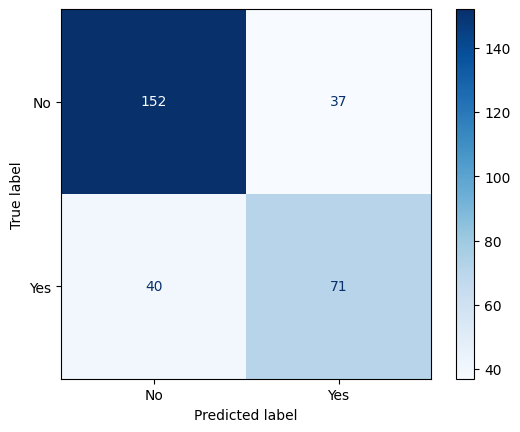

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, 
                      y_pred, 
                      labels=[0, 1])

disp = ConfusionMatrixDisplay(cm, 
                              display_labels=['No', 'Yes']).plot(cmap='Blues')


# feature importance